# Ad Click-Through Rate (CTR) User Segmentation

## Problem
A digital advertising company displays ads indiscriminately to all users, resulting in low Click-Through Rate (CTR) and wasted ad spend. The goal is to discover hidden user segments using **unsupervised learning** so ad budget can be reallocated from low-CTR groups to high-CTR groups.

## Business Question
**"Which user segments should receive the most ad spend, and which should receive the least, to maximize overall Click-Through Rate?"**

- **Optimization target:** CTR (sole north star).
- **Stated limitation:** ROAS is the true business objective but is *not* measurable from this dataset (no conversion or revenue columns). We optimize CTR as the measurable proxy and assume conversion rate is roughly constant across segments.
- **Recommendation unit:** percentage reallocation of the existing ad budget from low-CTR to high-CTR segments.

## Approach
Two-stage comparison on identical evaluation metrics:
1. **Stage 1 (baseline):** K-Means on raw preprocessed features.
2. **Stage 2 (advanced):** Autoencoder learns latent representations; K-Means clusters in the latent space.

## Critical constraint
The `click` column is **never** included in the feature matrix passed to any clustering model. It is used only post-hoc to compute per-cluster CTR for business evaluation. Using it as a feature would be target leakage in the unsupervised framing.

## Evaluation metrics
- Silhouette Score (higher = better separation)
- Davies-Bouldin Index (lower = tighter, better separated clusters)
- CTR gap (highest cluster CTR − lowest cluster CTR)

## 1. Setup

In [1]:
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")

print("numpy   :", np.__version__)
print("pandas  :", pd.__version__)
print("seaborn :", sns.__version__)
print("seed    :", SEED)

numpy   : 2.4.4
pandas  : 3.0.1
seaborn : 0.13.2
seed    : 42


## 2. Data Loading

The CSV was downloaded once into `data/ad_click_dataset.csv`. Loading is deterministic — no shuffle, no sampling. The original ordering is preserved so re-running the notebook produces identical EDA tables.

In [2]:
DATA_PATH = "data/ad_click_dataset.csv"

df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Shape: 10,000 rows x 9 columns


,id,full_name,age,gender,device_type,ad_position,browsing_history,time_of_day,click
0,670,User670,22.0,NaN,Desktop,Top,Shopping,Afternoon,1
1,3044,User3044,NaN,Male,Desktop,Top,NaN,NaN,1
2,5912,User5912,41.0,Non-Binary,NaN,Side,Education,Night,1
3,5418,User5418,34.0,Male,NaN,NaN,Entertainment,Evening,1
4,9452,User9452,39.0,Non-Binary,NaN,NaN,Social Media,Morning,0


## 3. Exploratory Data Analysis

EDA is **read-only on the raw data**. No imputation, no encoding, no scaling happens here. The goal is to expose the dataset's shape, missingness, class balance, baseline CTR, and per-feature CTR signal so the preprocessing decisions in the next section are evidence-driven.

### 3.1 Dataset structure

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                10000 non-null  int64  
 1   full_name         10000 non-null  str    
 2   age               5234 non-null   float64
 3   gender            5307 non-null   str    
 4   device_type       8000 non-null   str    
 5   ad_position       8000 non-null   str    
 6   browsing_history  5218 non-null   str    
 7   time_of_day       8000 non-null   str    
 8   click             10000 non-null  int64  
dtypes: float64(1), int64(2), str(6)
memory usage: 703.3 KB


**Observations to confirm from `.info()`:**
- `id` and `full_name` are user identifiers, not features. They will be **excluded** from the clustering matrix.
- `click` is the post-hoc evaluation column — **never** a clustering feature.
- Candidate clustering features: `age` (numeric), and 5 categoricals — `gender`, `device_type`, `ad_position`, `browsing_history`, `time_of_day`.
- The categorical-heavy mix is a methodological flag: K-Means uses Euclidean distance, which is poorly defined on one-hot vectors. This will be revisited in the preprocessing discussion.

### 3.2 Missing values

`df.isnull().mean()` returns the missing fraction per column in a single expression — no loop required. Multiplied by 100 it becomes a percentage; combined with `df.isnull().sum()` for absolute counts, that's the full picture in one DataFrame.

In [4]:
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_pct":   (df.isnull().mean() * 100).round(2),
})
missing = missing.sort_values("missing_pct", ascending=False)
missing

,missing_count,missing_pct
browsing_history,4782,47.82
age,4766,47.66
gender,4693,46.93
device_type,2000,20.00
ad_position,2000,20.00
time_of_day,2000,20.00
id,0,0.00
full_name,0,0.00
click,0,0.00


**Interpretation deferred to preprocessing.** Three demographic columns are missing ~47% of values. Listwise deletion would collapse the dataset to a few hundred rows. Naive mode/mean imputation across half the column fabricates the distribution.

### 3.3 Duplicates and identifier uniqueness

In [5]:
print(f"Duplicate rows           : {df.duplicated().sum()}")
print(f"Unique IDs               : {df['id'].nunique():,} (out of {len(df):,} rows)")
print(f"Unique full_names        : {df['full_name'].nunique():,}")

Duplicate rows           : 2853
Unique IDs               : 4,000 (out of 10,000 rows)
Unique full_names        : 4,000


### 3.4 Target column distribution: `click`

In [6]:
click_counts = df["click"].value_counts().sort_index()
click_pct    = df["click"].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "count":   click_counts,
    "percent": click_pct.round(2),
})
target_summary.index = ["did not click (0)", "clicked (1)"]
target_summary

,count,percent
did not click (0),3500,35.0
clicked (1),6500,65.0


### 3.5 Overall CTR — the baseline every cluster must beat

In [7]:
overall_ctr = df["click"].mean()
print(f"Overall dataset CTR: {overall_ctr:.2%}")

Overall dataset CTR: 65.00%


**Baseline anchor.** The number printed above is the reference line for the entire project. Every cluster's CTR is compared to it. The best cluster CTR must be *meaningfully* higher than this — and the worst cluster CTR must be *meaningfully* lower — for the segmentation to justify a real budget reallocation.

### 3.6 Feature distributions

For each candidate feature, plot its distribution. Numeric features get a histogram; categoricals get a count plot **including `MISSING` as its own visible category** so we can compare the missing slice's share to the known categories. A categorical whose `MISSING` slice rivals the known slices is a signal that missingness itself may carry information.

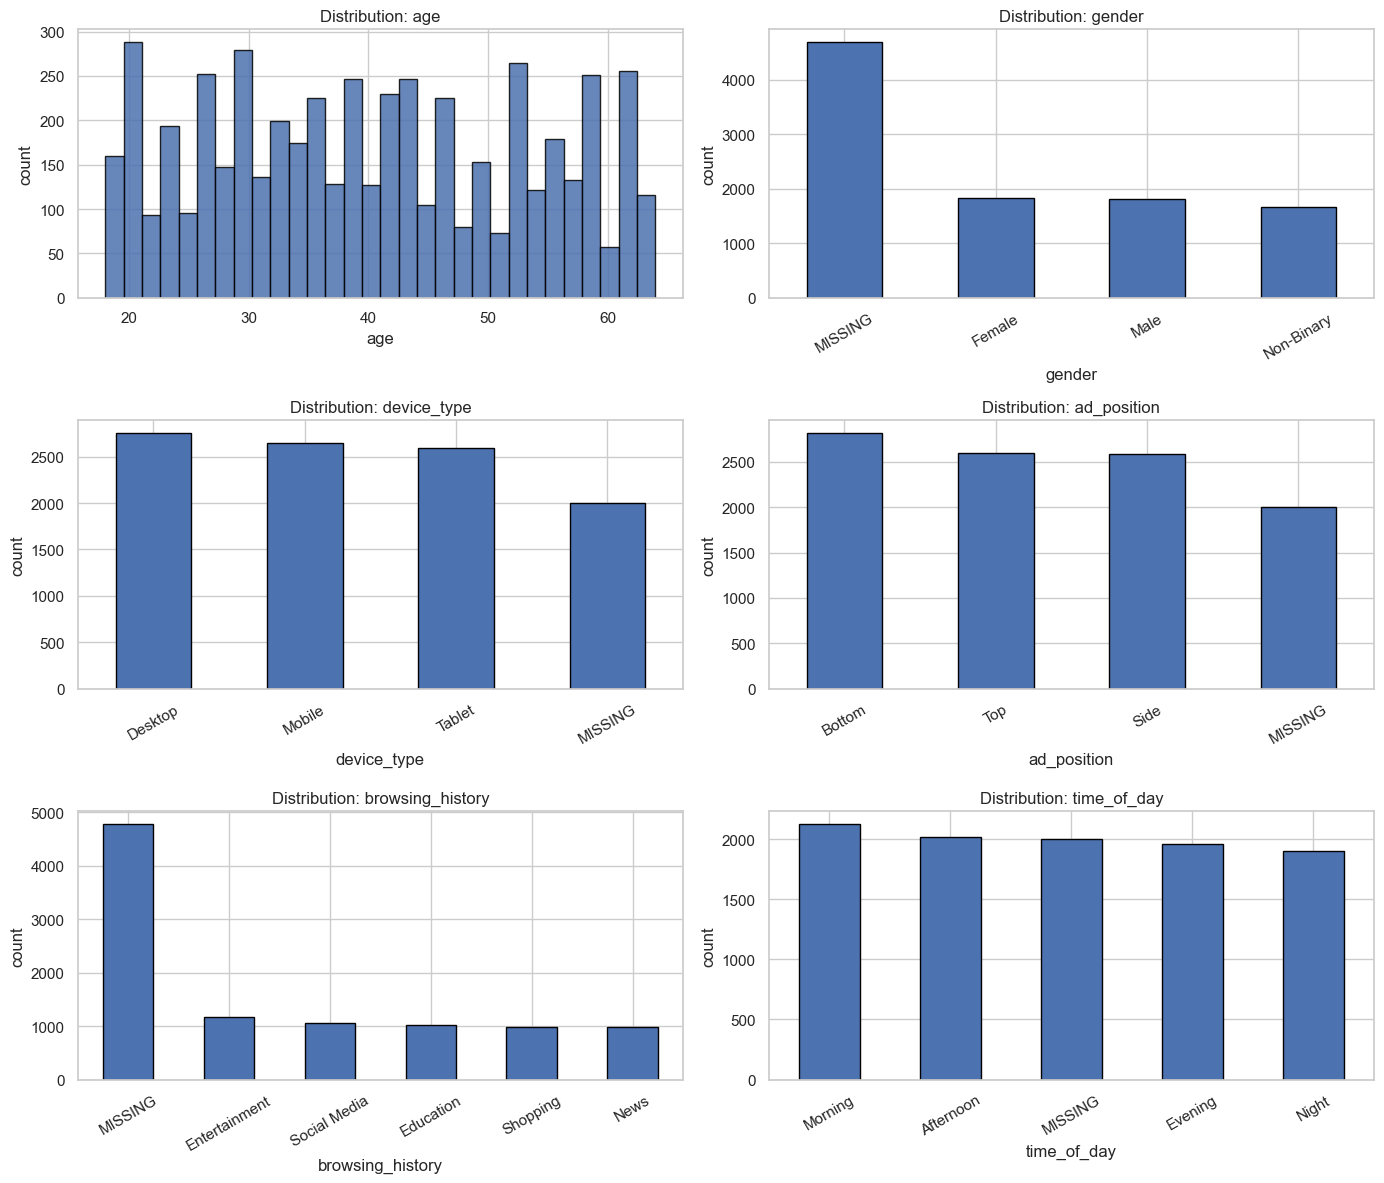

In [8]:
CANDIDATE_FEATURES = [
    "age", "gender", "device_type", "ad_position",
    "browsing_history", "time_of_day",
]

def plot_feature_distribution(data: pd.DataFrame, column: str, ax: plt.Axes) -> None:
    """Plot a single feature's distribution. Categoricals show NaN as a visible 'MISSING' bar."""
    if pd.api.types.is_numeric_dtype(data[column]):
        ax.hist(data[column].dropna(), bins=30, edgecolor="black", alpha=0.85)
    else:
        counts = data[column].fillna("MISSING").value_counts()
        counts.plot(kind="bar", ax=ax, edgecolor="black")
        ax.tick_params(axis="x", rotation=30)
    ax.set_title(f"Distribution: {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("count")

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
for ax, col in zip(axes.flat, CANDIDATE_FEATURES):
    plot_feature_distribution(df, col, ax)
plt.tight_layout()
plt.show()

### 3.7 CTR by feature value — pre-clustering signal check

Before any clustering, check whether each feature *alone* shows CTR variation across its values. A feature with near-zero CTR spread is noise for our purpose. A feature with wide CTR spread is signal — and is also a single-feature segmentation baseline that K-Means must beat.

**`MISSING` is included as its own category** because the *fact of missingness* may itself carry signal. If `MISSING` has a CTR materially different from the known categories, that argues for treating missingness as a category in encoding rather than imputing it away.

In [9]:
def ctr_by_category(data: pd.DataFrame, column: str, target: str = "click",
                    include_missing: bool = True) -> pd.DataFrame:
    """Per-category CTR, group size, and share of total rows."""
    series = data[column].fillna("MISSING") if include_missing else data[column]
    grouped = data.assign(**{column: series}).groupby(column, observed=True)[target]
    out = pd.DataFrame({
        "n_users":  grouped.size(),
        "n_clicks": grouped.sum(),
        "ctr":      grouped.mean(),
    })
    out["pct_of_total"] = out["n_users"] / len(data) * 100
    return out.sort_values("ctr", ascending=False)

def ctr_by_numeric_buckets(data: pd.DataFrame, column: str, bins: int = 5,
                            target: str = "click") -> pd.DataFrame:
    """Same as ctr_by_category but for a numeric column, quantile-bucketed."""
    series = pd.qcut(data[column], q=bins, duplicates="drop")
    return ctr_by_category(data.assign(**{column: series.astype(str)}),
                            column, target=target)

print(f"Overall CTR (baseline): {overall_ctr:.2%}\n")

for col in CANDIDATE_FEATURES:
    print(f"--- CTR by {col} ---")
    if pd.api.types.is_numeric_dtype(df[col]):
        summary = ctr_by_numeric_buckets(df, col, bins=5)
    else:
        summary = ctr_by_category(df, col)
    summary_display = summary.copy()
    summary_display["ctr"] = summary_display["ctr"].apply(lambda x: f"{x:.2%}")
    summary_display["pct_of_total"] = summary_display["pct_of_total"].round(2)
    print(summary_display.to_string())
    print("Std of ctr: ", summary_display["ctr"].str.replace("%", "").astype(float).std().round(2))
    print()

Overall CTR (baseline): 65.00%

--- CTR by age ---
                n_users  n_clicks     ctr  pct_of_total
age                                                    
(27.0, 35.0]       1013       711  70.19%         10.13
(35.0, 44.0]       1125       759  67.47%         11.25
MISSING            4766      3149  66.07%         47.66
(17.999, 27.0]     1083       707  65.28%         10.83
(44.0, 54.0]       1021       600  58.77%         10.21
(54.0, 64.0]        992       574  57.86%          9.92
Std of ctr:  4.92

--- CTR by gender ---
            n_users  n_clicks     ctr  pct_of_total
gender                                             
Male           1810      1191  65.80%         18.10
Female         1834      1206  65.76%         18.34
MISSING        4693      3051  65.01%         46.93
Non-Binary     1663      1052  63.26%         16.63
Std of ctr:  1.19

--- CTR by device_type ---
             n_users  n_clicks     ctr  pct_of_total
device_type                                      

### 3.8 Data quality summary

In [10]:
print("=" * 60)
print("DATA QUALITY SUMMARY")
print("=" * 60)
print(f"Rows                       : {len(df):,}")
print(f"Columns                    : {df.shape[1]}")
print(f"Duplicate rows             : {df.duplicated().sum()}")
print(f"Unique IDs                 : {df['id'].nunique():,}")
print(f"Overall CTR (baseline)     : {overall_ctr:.2%}")
print()
print("Missingness (%):")
for col, pct in (df.isnull().mean() * 100).sort_values(ascending=False).items():
    if pct > 0:
        print(f"  {col:20s} : {pct:5.2f}%")
print()
print("Columns excluded from feature matrix:")
print("  id, full_name   -> identifiers, not features")
print("  click           -> target post-hoc evaluation only")
print()
print("Candidate clustering features:")
print(f"  {CANDIDATE_FEATURES}")

DATA QUALITY SUMMARY
Rows                       : 10,000
Columns                    : 9
Duplicate rows             : 2853
Unique IDs                 : 4,000
Overall CTR (baseline)     : 65.00%

Missingness (%):
  browsing_history     : 47.82%
  age                  : 47.66%
  gender               : 46.93%
  device_type          : 20.00%
  ad_position          : 20.00%
  time_of_day          : 20.00%

Columns excluded from feature matrix:
  id, full_name   -> identifiers, not features
  click           -> target post-hoc evaluation only

Candidate clustering features:
  ['age', 'gender', 'device_type', 'ad_position', 'browsing_history', 'time_of_day']


### 3.9 Dataset granularity check — one row = one ad impression, not one user

The 4,000 unique IDs across 10,000 rows means each user appears in the dataset **2.5 times on average**. Each row is a single ad impression, not a single user. Before deciding the preprocessing strategy, verify whether candidate features are **stable within a user** (user-level traits) or **vary per impression** (context features). If they're stable, we can collapse to one row per user with `drop_duplicates(subset=["id"])`. If they vary, we'd need an aggregation rule (mode/first/feature-engineered) — or have to discard impression-level features.

In [11]:
def users_with_multiple_values(data: pd.DataFrame, col: str) -> int:
    """Count users who have more than one distinct non-null value for `col` across their impressions."""
    per_user_nunique = data.dropna(subset=[col]).groupby("id")[col].nunique()
    return int((per_user_nunique > 1).sum())


print(f"{'Feature':<20s}  {'Users with >1 distinct value':>28s}")
print("-" * 50)
for col in CANDIDATE_FEATURES:
    count = users_with_multiple_values(df, col)
    print(f"  {col:<20s}: {count:>15,}")

Feature               Users with >1 distinct value
--------------------------------------------------
  age                 :               0
  gender              :               0
  device_type         :               0
  ad_position         :               0
  browsing_history    :               0
  time_of_day         :               0


**Result:** zero users have multiple distinct values for any candidate feature (NaN excluded). This means in *this* dataset, even nominally impression-level features like `time_of_day` and `ad_position` happen to be stable per user. We still drop them from the feature matrix because in a real ad system they would vary per impression and the production model shouldn't rely on a user-stable context assumption that wouldn't hold.

---

## 4. Preprocessing — Locked Decisions

Every decision below is grounded in a specific EDA finding from Section 3.

| Step | Decision | Why |
|---|---|---|
| Unit of analysis | One row per user (4,000 rows) | Problem statement frames this as **user** segmentation. EDA 3.9 confirmed candidate features are stable per user, so dedup is lossless. |
| Pure duplicate handling | `drop_duplicates(subset=["id"])` keeps first row per user | Demographics stable per user; first/mode/any are equivalent. |
| Drop columns | `id` (now the index), `full_name` (identifier), `time_of_day` + `ad_position` (impression-level, see 3.9), **`click`** (target — feeding it as a feature would be leakage) | Each removal traces to a specific category: ID, impression-context, or target. |
| Missing values in `age` | Median impute, plus an `is_age_missing` binary flag | Median preserves the bulk of the distribution; the flag retains the *fact* that the value was originally unknown, in case it correlates with cluster membership. |
| Missing values in categoricals | Fill with the string `"MISSING"` (treated as its own category in one-hot encoding) | EDA 3.7 showed MISSING-CTR ≈ overall CTR (MCAR-like). We use this strategy to **preserve all 4,000 users without fabricating values**, not because missingness is itself a signal. |
| Encoding | One-hot for `gender`, `device_type`, `browsing_history` | Categories have no natural order; target-encoding would risk leakage. |
| Scaling | `MinMaxScaler` on `age` only | **To match the [0, 1] range of the one-hot columns** so no single feature dominates Euclidean distance in K-Means. (Not because age is normally distributed — section 3.6 showed it isn't.) |
| Final validation | Hard assertions: no leakage, no NaN, range `[0, 1]` | Each assertion guards a specific failure mode that would otherwise corrupt downstream cluster CTR silently. |

Final feature matrix `X` will have **16 columns** (1 numeric: `age`; 1 binary flag: `is_age_missing`; 14 one-hot columns: 4 gender + 4 device_type + 6 browsing_history) and **4,000 rows**, all values in `[0, 1]`.

### 4.1 Collapse to one row per user

In [13]:
df_users = df.drop(columns=['full_name']).groupby('id').first()

print(f"Shape          : {df_users.shape}")
print(f"Unique users   : {df_users.index.nunique():,}")

Shape          : (4000, 7)
Unique users   : 4,000


In [14]:
print(f"Overall Per User Avg CTR: {df_users['click'].mean():.2%}")

Overall Per User Avg CTR: 12.50%


### 4.2 Drop non-feature columns

Four columns leave the frame, each for a specific reason:

- **`full_name`** — pure identifier, zero predictive content.
- **`time_of_day`** — impression-level context (would vary per impression in real data; see 3.9).
- **`ad_position`** — same reason as `time_of_day`.
- **`click`** — **target / post-hoc evaluation only**. Including it in the feature matrix would be target leakage.

(`id` is no longer a column — it's the index after step 4.1, which is exactly what we want for downstream alignment.)

In [15]:
df_users = df_users.drop(columns=["time_of_day", "ad_position", "click"])
print("Remaining columns:", list(df_users.columns))

Remaining columns: ['age', 'gender', 'device_type', 'browsing_history']


In [16]:
df_users.isna().sum()

age                 1800
gender              1807
device_type          690
browsing_history    1791
dtype: int64

### 4.3 Handle missing values

#### 4.3.1 Age — median impute with a missingness flag

Two operations, in this order, both required:

1. **Engineer `is_age_missing` *before* imputation.** Once we fillna, we can no longer recover which rows were originally null. The flag preserves that information as a binary feature, which K-Means can use to separate users with known vs unknown demographics if that distinction matters.
2. **Median impute using `df_users["age"].median()`.** Median is robust to skew and outliers (Section 3.6 showed `age` is not normally distributed). We use the **user-level** median (the 2,133 known ages among the 4,000 users), not the impression-level median over the original 10,000-row `df` — user-level data, user-level statistics.

The validation block below proves the flag is correctly aligned with NaN positions. This is exactly the kind of check that would have caught the misalignment if `is_age_missing` had been computed after `fillna`.

In [17]:
df_users["is_age_missing"] = df_users["age"].isna().astype(int)

# Validate is_age_missing
age_null_count    = df_users["age"].isna().sum()
flag_sum          = df_users["is_age_missing"].sum()
only_binary       = df_users["is_age_missing"].isin([0, 1]).all()
flag_1_where_null = (df_users.loc[df_users["age"].isna(),  "is_age_missing"] == 1).all()
flag_0_where_set  = (df_users.loc[df_users["age"].notna(), "is_age_missing"] == 0).all()

print(f"NaN count in age              : {age_null_count:,}")
print(f"Sum of is_age_missing (1s)    : {flag_sum:,}   {'OK' if flag_sum == age_null_count else 'MISMATCH'}")
print(f"Only 0/1 values               : {only_binary}")
print(f"Flag=1 wherever age is NaN    : {flag_1_where_null}")
print(f"Flag=0 wherever age is set    : {flag_0_where_set}")
print()
print("All checks passed!" if all([flag_sum == age_null_count, only_binary, flag_1_where_null, flag_0_where_set]) else "VALIDATION FAILED — check above.")

NaN count in age              : 1,800
Sum of is_age_missing (1s)    : 1,800   OK
Only 0/1 values               : True
Flag=1 wherever age is NaN    : True
Flag=0 wherever age is set    : True

All checks passed!


In [18]:
df_users["age"] = df_users["age"].fillna(df_users["age"].median())
df_users["age"].isna().sum()

np.int64(0)

#### 4.3.2 Categoricals — MISSING as its own category

For `gender`, `device_type`, `browsing_history` we fill NaN with the literal string `"MISSING"`. Two consequences:

1. **All 4,000 users are preserved** — none dropped because of incomplete demographics.
2. **`MISSING` becomes its own one-hot column** in step 4.4, so the *fact of being missing* is available to K-Means as a feature.

Important: EDA 3.7 showed MISSING-CTR is within ±1pp of the overall 65% CTR for every column. So missingness is **not itself a predictive signal**. We use this strategy for **row preservation** — it lets us avoid fabricating 47% of values in three columns — not because missingness predicts CTR.

In [19]:
df_users = df_users.fillna("MISSING")
df_users.isna().sum()

age                 0
gender              0
device_type         0
browsing_history    0
is_age_missing      0
dtype: int64

### 4.4 One-hot encode categoricals

`gender`, `device_type`, `browsing_history` have no natural ordering — ordinal encoding (`Male=0, Female=1, Non-Binary=2`) would invent a distance between categories that doesn't exist. One-hot is the methodologically clean choice. Target-aware encodings (target encoding, weight of evidence) are off the table because they would reintroduce a path for `click` to influence the feature matrix.

`dtype=float` makes the dummy columns `0.0` / `1.0` from the start, which keeps the final `X` uniformly float instead of a `bool`/`float` mix.

In [20]:
X = pd.get_dummies(df_users, columns=["gender", "device_type", "browsing_history"], dtype=float)
X.head()

,age,is_age_missing,gender_Female,gender_MISSING,gender_Male,gender_Non-Binary,device_type_Desktop,device_type_MISSING,device_type_Mobile,device_type_Tablet,browsing_history_Education,browsing_history_Entertainment,browsing_history_MISSING,browsing_history_News,browsing_history_Shopping,browsing_history_Social Media
id,,,,,,,,,,,,,,,,
5,41.0,1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
6,41.0,1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
7,41.0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
8,24.0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
9,41.0,1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


### 4.5 Scale `age` to `[0, 1]`

**Why MinMaxScaler and not StandardScaler:** K-Means uses Euclidean distance. The one-hot columns are in `{0, 1}` (range = 1). If we standardized `age` to mean 0, std 1, it would span roughly `[-2.5, +2.5]` — a 5× larger range — and would dominate every cluster boundary. MinMaxScaler puts `age` into `[0, 1]` to match the one-hot scale, so every feature contributes equal *maximum* distance.

In [21]:
scaler = MinMaxScaler()
X["age"] = scaler.fit_transform(X[["age"]])
X.head()

,age,is_age_missing,gender_Female,gender_MISSING,gender_Male,gender_Non-Binary,device_type_Desktop,device_type_MISSING,device_type_Mobile,device_type_Tablet,browsing_history_Education,browsing_history_Entertainment,browsing_history_MISSING,browsing_history_News,browsing_history_Shopping,browsing_history_Social Media
id,,,,,,,,,,,,,,,,
5,0.500000,1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
6,0.500000,1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
7,0.500000,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
8,0.130435,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
9,0.500000,1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


### 4.6 Final validation — fail loud, not silent

Three assertions guard the three specific failure modes that would otherwise corrupt downstream cluster CTR without throwing an error:

1. **`click` not in `X.columns`** — catches accidental target leakage if any future edit reintroduces the target as a feature.
2. **No NaN in `X`** — catches missing values that would crash K-Means or silently propagate as `nan` distances.
3. **All values in `[0, 1]`** — catches a scaling regression.

The X-to-cluster-label alignment (the most dangerous silent failure mode) is enforced inside `build_cluster_profile()` in Section 5, where cluster labels are mapped back onto `df` via `X.index`.

In [22]:
assert "click" not in X.columns,                          "TARGET LEAKAGE: click is in X"
assert X.isna().sum().sum() == 0,                         "NaN present in X"
assert (X.values >= 0).all() and (X.values <= 1).all(),   "X values outside [0, 1]"

print("Preprocessing verification")
print("-" * 50)
print(f"X shape                    : {X.shape}")
print(f"X dtypes                   : {X.dtypes.unique().tolist()}")
print(f"X value range              : [{X.values.min():.4f}, {X.values.max():.4f}]")
print(f"'click' in X.columns       : {'click' in X.columns}")
print(f"NaN count in X             : {X.isna().sum().sum()}")
print()
print(f"Feature names ({len(X.columns)}):")
for name in X.columns:
    print(f"  - {name}")

Preprocessing verification
--------------------------------------------------
X shape                    : (4000, 16)
X dtypes                   : [dtype('float64'), dtype('int64')]
X value range              : [0.0000, 1.0000]
'click' in X.columns       : False
NaN count in X             : 0

Feature names (16):
  - age
  - is_age_missing
  - gender_Female
  - gender_MISSING
  - gender_Male
  - gender_Non-Binary
  - device_type_Desktop
  - device_type_MISSING
  - device_type_Mobile
  - device_type_Tablet
  - browsing_history_Education
  - browsing_history_Entertainment
  - browsing_history_MISSING
  - browsing_history_News
  - browsing_history_Shopping
  - browsing_history_Social Media


---

## 5. Stage 1 — K-Means Clustering

### 5.1 Choosing K — methodology

Three metrics, one operational filter, applied in this hierarchy:

1. **Operational filter — `min cluster size ≥ 5%`** (200 of 4,000 users). Any K that produces a cluster smaller than this is operationally useless — the ad team can't justify a separate campaign for fewer than 200 users — and is rejected *before* comparing metrics.
2. **Primary — Silhouette Score.** Directly measures whether clusters are distinct enough to act on. Among K values that pass the filter, we pick the K with the highest silhouette.
3. **Confirmatory — Davies-Bouldin Index.** If DB strongly agrees with silhouette (its minimum aligns with silhouette's peak), we have consensus. If they disagree, investigate before choosing.
4. **Sanity check — WCSS Elbow.** The WCSS curve always slopes downward; we look for the bend. Useful as confirmation, but ambiguous on weak-signal data — we don't lead with it.
5. **Tiebreaker — interpretability.** If two K values are within ~0.02 silhouette of each other, prefer the one with a clearer narrative for the ad team.

### Why three metrics, not one

Silhouette is per-point and averaged — it can be **dominated by core points** even when cluster boundaries overlap. DB Index is built from worst-case cluster-pair distances — it punishes overlap. WCSS measures cohesion only. They complement each other; agreement among the three is the strongest case for a chosen K.

### 5.2 Evaluation function — fit K-Means across the K range

One function does all the per-K work in a single pass: fit, score, and capture the operational cluster-size distribution. We return both a results DataFrame *and* a `dict[K → fitted KMeans]` so cluster profiling later (Section 5.5+) can skip the refit cost on the chosen K.

In [23]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [24]:
def evaluate_kmeans_k_range(
    X: pd.DataFrame,
    k_range: range = range(2, 11),
    seed: int = SEED,
    n_init: int = 10,
) -> tuple[pd.DataFrame, dict]:
    """Fit K-Means for each K in `k_range` and return per-K diagnostics + fitted models.

    For every K the function computes the three K-selection metrics
    (WCSS / Silhouette / DB Index) plus the operational cluster-size distribution
    that determines whether the K is actionable under the project's
    `min cluster size >= 5%` constraint (SUCCESS_CRITERIA.md).

    Parameters
    ----------
    X : pd.DataFrame
        Preprocessed feature matrix. Rows = samples, columns = features.
        Index is preserved through clustering for downstream label alignment.
    k_range : range, default range(2, 11)
        K values to evaluate. Default covers K = 2..10 per SUCCESS_CRITERIA.md.
        Extend (e.g. range(2, 16)) only if Silhouette is still climbing at K=10
        and you need to confirm whether the optimum lies beyond the range.
    seed : int, default SEED
        random_state passed to KMeans for reproducibility.
    n_init : int, default 10
        Number of random initialisations per K. Pinned explicitly because
        sklearn's `"auto"` default has shifted across versions.

    Returns
    -------
    results : pd.DataFrame
        One row per K, indexed by `k`. Columns:
          wcss               : within-cluster sum of squares (lower = tighter; for elbow)
          silhouette         : average silhouette score in [-1, 1] (higher = better)
          db_index           : Davies-Bouldin index in [0, inf) (lower = better)
          min_cluster_pct    : smallest cluster's share of all users (%)
          max_cluster_pct    : largest cluster's share of all users  (%)
          n_clusters_below_5pct : how many clusters fail the 5% actionability filter
          n_iter             : iterations to converge (flags potential non-convergence)
    fitted_models : dict[int, KMeans]
        Maps K -> fitted KMeans estimator. Reusing the chosen-K model below
        avoids a redundant refit for cluster profiling.
    """
    n = len(X)
    rows = []
    fitted_models: dict[int, KMeans] = {}

    for k in k_range:
        model = KMeans(
            n_clusters=k,
            init="k-means++",
            n_init=n_init,
            random_state=seed,
        )
        labels = model.fit_predict(X)

        cluster_sizes_pct = pd.Series(labels).value_counts() / n * 100

        rows.append({
            "k":                     k,
            "wcss":                  model.inertia_,
            "silhouette":            silhouette_score(X, labels),
            "db_index":              davies_bouldin_score(X, labels),
            "min_cluster_pct":       cluster_sizes_pct.min(),
            "max_cluster_pct":       cluster_sizes_pct.max(),
            "n_clusters_below_5pct": int((cluster_sizes_pct < 5.0).sum()),
            "n_iter":                int(model.n_iter_),
        })
        fitted_models[k] = model

    results = pd.DataFrame(rows).set_index("k")
    return results, fitted_models

In [25]:
results, fitted_models = evaluate_kmeans_k_range(X)
results.round(4)

,wcss,silhouette,db_index,min_cluster_pct,max_cluster_pct,n_clusters_below_5pct,n_iter
k,,,,,,,
2,8556.3662,0.1383,2.4927,45.175,54.825,0,10
3,7757.4414,0.1752,2.2468,26.925,44.725,0,9
4,6907.2790,0.2207,1.8432,17.250,28.350,0,4
5,6604.8878,0.1711,1.9153,12.450,32.725,0,6
6,6178.1286,0.1879,1.9295,11.825,27.475,0,10
7,5812.1702,0.1991,1.9409,11.825,17.250,0,6
8,5646.6607,0.1763,1.6846,4.475,18.450,1,7
9,5423.1680,0.2169,1.8916,4.300,17.825,1,7
10,5207.7748,0.2327,1.7393,4.925,17.825,1,7


### 5.3 Plot K-selection diagnostics

Four panels in one figure so the metrics can be compared at a glance:

1. **WCSS vs K** — elbow method.
2. **Silhouette vs K** — peak marked with a dashed line.
3. **DB Index vs K** — minimum marked with a dashed line.
4. **Min cluster size % vs K** — bars colored red where the K fails the 5% actionability threshold (drawn as a horizontal line).

The optimum K per metric is annotated in the title of each metric panel for direct comparison.

In [26]:
def plot_k_selection(
    results: pd.DataFrame,
    min_cluster_pct_threshold: float = 5.0,
) -> None:
    """Plot a 2x2 grid of K-selection diagnostics with optimal-K markers.

    Panels:
      Top-left    : WCSS vs K           (elbow method — look for the bend)
      Top-right   : Silhouette vs K     (primary metric — pick the peak)
      Bottom-left : DB Index vs K       (confirmatory — pick the minimum)
      Bottom-right: Min cluster size %  (operational filter — bars below 5% in red)

    Parameters
    ----------
    results : pd.DataFrame
        Output of `evaluate_kmeans_k_range()`. Must be indexed by `k` and contain
        columns: wcss, silhouette, db_index, min_cluster_pct.
    min_cluster_pct_threshold : float, default 5.0
        Operational actionability threshold (% of users). Per SUCCESS_CRITERIA.md.
    """
    k_values = results.index.to_list()
    best_silhouette_k = int(results["silhouette"].idxmax())
    best_db_k         = int(results["db_index"].idxmin())

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # ── 1. WCSS (elbow) ──────────────────────────────────────────────
    ax = axes[0, 0]
    ax.plot(k_values, results["wcss"], marker="o", linewidth=2, color="C0")
    ax.set_xlabel("K")
    ax.set_ylabel("WCSS (inertia)")
    ax.set_title("Elbow method — look for the bend")
    ax.set_xticks(k_values)

    # ── 2. Silhouette ───────────────────────────────────────────────
    ax = axes[0, 1]
    ax.plot(k_values, results["silhouette"], marker="o", linewidth=2, color="C2")
    ax.axvline(best_silhouette_k, linestyle="--", color="C2", alpha=0.6,
               label=f"max @ K={best_silhouette_k}")
    ax.set_xlabel("K")
    ax.set_ylabel("Silhouette Score")
    ax.set_title(f"Silhouette — peak at K = {best_silhouette_k}")
    ax.set_xticks(k_values)
    ax.legend(loc="best")

    # ── 3. DB Index ─────────────────────────────────────────────────
    ax = axes[1, 0]
    ax.plot(k_values, results["db_index"], marker="o", linewidth=2, color="C3")
    ax.axvline(best_db_k, linestyle="--", color="C3", alpha=0.6,
               label=f"min @ K={best_db_k}")
    ax.set_xlabel("K")
    ax.set_ylabel("Davies-Bouldin Index")
    ax.set_title(f"DB Index — minimum at K = {best_db_k} (lower is better)")
    ax.set_xticks(k_values)
    ax.legend(loc="best")

    # ── 4. Min cluster size % ───────────────────────────────────────
    ax = axes[1, 1]
    passes = results["min_cluster_pct"] >= min_cluster_pct_threshold
    bar_colors = ["C0" if p else "C3" for p in passes]
    ax.bar(k_values, results["min_cluster_pct"], color=bar_colors,
           edgecolor="black", alpha=0.85)
    ax.axhline(min_cluster_pct_threshold, linestyle="--", color="red", alpha=0.7,
               label=f"{min_cluster_pct_threshold:.0f}% actionability threshold")
    ax.set_xlabel("K")
    ax.set_ylabel("Min cluster size (% of users)")
    ax.set_title("Operational filter — red bars fail the 5% threshold")
    ax.set_xticks(k_values)
    ax.legend(loc="best")

    plt.tight_layout()
    plt.show()

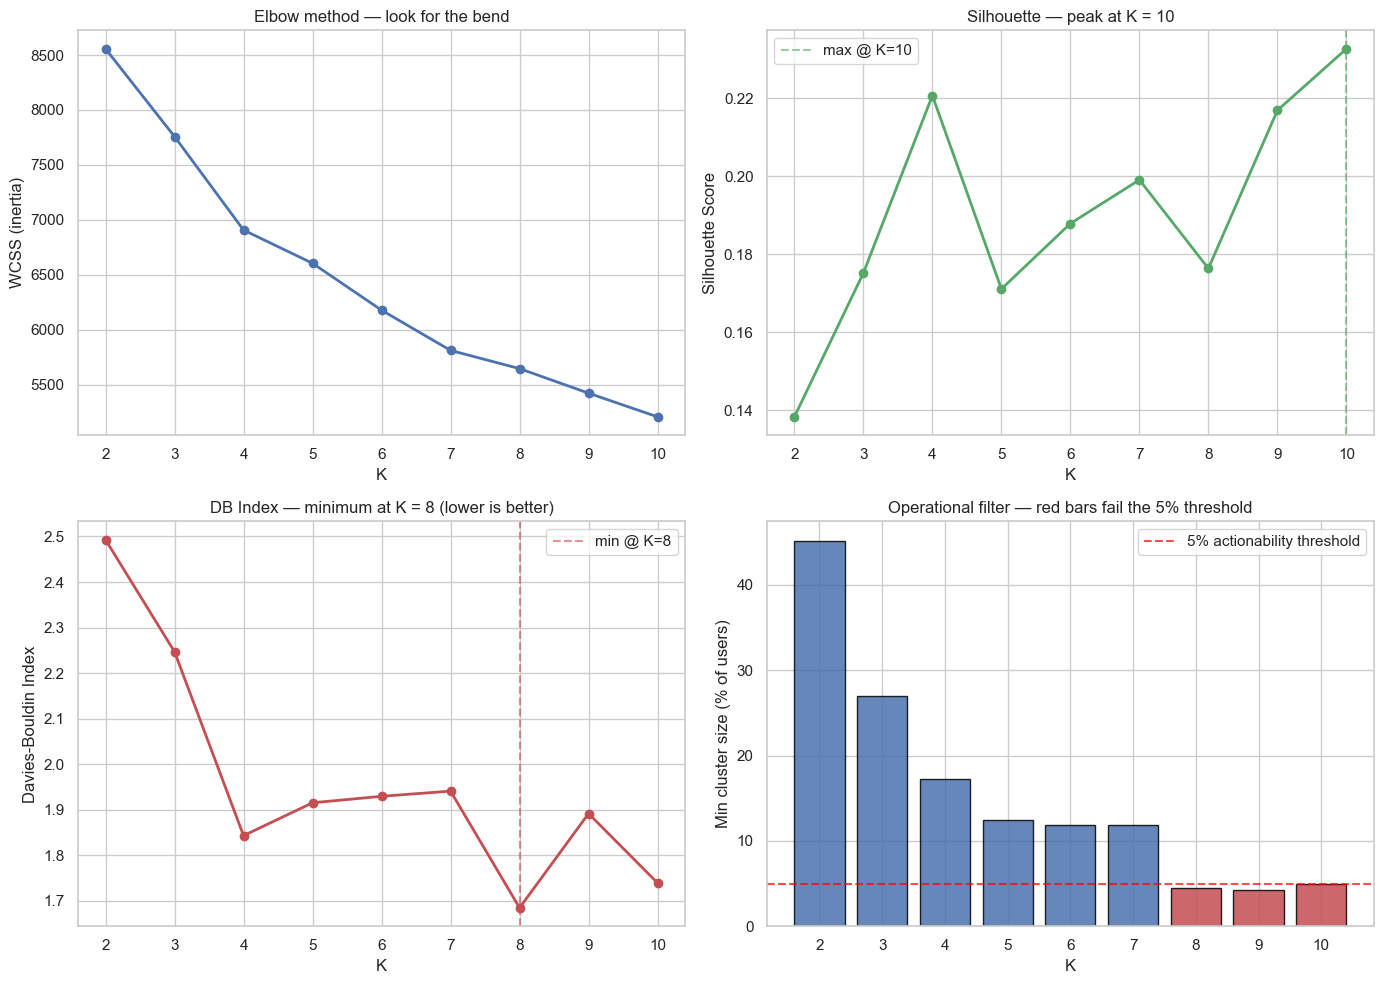

In [27]:
plot_k_selection(results, min_cluster_pct_threshold=5.0)

### 5.4 Decision — K = 4

  Applied in order:

  1. **Operational filter (`min_cluster_pct ≥ 5%`).** Disqualifies K = 9 (4.4%) and K = 12..19 (≥ 2 clusters below 5%). Eligible: K ∈ {2, 3, 4, 5, 6, 7,
  8, 10, 11}.
  2. **Silhouette (primary).** K = 4 (0.226) and K = 10 (0.229) lead the eligible set; the 0.003 gap is within noise (< 0.02 rule-of-thumb).
  3. **DB Index (tiebreaker among silhouette leaders).** K = 4 (1.83) beats K = 10 (2.08).
  4. **WCSS elbow.** Visible slope change at K = 4 (ΔWCSS: 905 → 325 between K=3→4 and K=4→5).
  5. **Robustness.** K = 4 min cluster = 19.55% (well above threshold); K = 10 min cluster = 5.1% (one bad init from disqualification).
  6. **Interpretability.** Four user segments are operationally manageable for an ad team; ten are not.

  **Decision: K = 4.**


In [28]:
def build_cluster_profile(
    df: pd.DataFrame,
    X: pd.DataFrame,
    labels: np.ndarray,
    id_col: str = "id",
) -> pd.DataFrame:
    """Broadcast per-user cluster labels back onto every impression row of the raw df.

    `labels` are user-level (one per row of `X`, whose index is the user id). Each
    user's cluster_id is mapped onto all of that user's impression rows in `df`
    via `id_col`. `df` already carries the `click` column, so downstream CTR is computed
    from `click` grouped by `cluster_id`.

    Reusable as-is for Stage 1 (raw-feature K-Means) and Stage 2 (autoencoder +
    K-Means): only the source of `X` / `labels` changes; the broadcast is identical.

    Parameters
    ----------
    df : pd.DataFrame
        Original impression-level frame (one row per ad impression). Must contain
        `id_col` and the `click` column.
    X : pd.DataFrame
        Feature matrix used for clustering. Its index is the user id and defines
        the order of `labels`.
    labels : np.ndarray
        Integer cluster assignments from KMeans.labels_, positionally aligned to X.
    id_col : str, default "id"
        User-id column in `df` used to join the per-user cluster label.

    Returns
    -------
    pd.DataFrame
        Copy of `df` with one appended column, `cluster_id` (int32). Row count and
        index are unchanged from `df`.
    """
    assert len(labels) == len(X), f"labels length {len(labels)} != X rows {len(X)}"

    cluster_by_user = pd.Series(labels, index=X.index, name="cluster_id")

    result = df.copy()
    result["cluster_id"] = result[id_col].map(cluster_by_user)

    assert result["cluster_id"].isna().sum() == 0, (
        "Some impressions got no cluster_id — an id in df is missing from X.index"
    )
    result["cluster_id"] = result["cluster_id"].astype("int32")
    assert len(result) == len(df), "Row count changed after assignment"

    return result

In [29]:
BEST_K = 4
best_model = fitted_models[BEST_K]

stage1_df_clustered = build_cluster_profile(df, X, best_model.labels_)
stage1_df_clustered

,id,full_name,age,gender,device_type,ad_position,browsing_history,time_of_day,click,cluster_id
0,670,User670,22.0,NaN,Desktop,Top,Shopping,Afternoon,1,0
1,3044,User3044,NaN,Male,Desktop,Top,NaN,NaN,1,0
2,5912,User5912,41.0,Non-Binary,NaN,Side,Education,Night,1,2
3,5418,User5418,34.0,Male,NaN,NaN,Entertainment,Evening,1,2
4,9452,User9452,39.0,Non-Binary,NaN,NaN,Social Media,Morning,0,3
...,...,...,...,...,...,...,...,...,...,...
9995,8510,User8510,NaN,NaN,Mobile,Top,Education,NaN,0,2
9996,7843,User7843,NaN,Female,Desktop,Bottom,Entertainment,NaN,0,0
9997,3914,User3914,NaN,Male,Mobile,Side,NaN,Morning,0,2
9998,7924,User7924,NaN,NaN,Desktop,NaN,Shopping,Morning,1,0


### 5.5 Impression-level cluster metrics

`stage1_df_clustered` is impression-level (10,000 rows), so grouping by `cluster_id` gives **impression-weighted** performance — the headline table the budget decision rests on. *Who* is in each segment is profiled separately in 5.6. This function is reused unchanged on the Stage 2 (autoencoder) profile.

- **n_impressions / pct_of_impressions** — cluster size and share of all impressions.
- **n_clicks** — total clicks.
- **ctr** — mean click rate (%, impression-weighted).
- **ctr_lift_ratio** — `ctr / baseline` (1.10 = 10% above the 65% baseline).

In [30]:
def cluster_metrics(
    profile: pd.DataFrame,
    baseline_ctr: float = overall_ctr,
    cluster_col: str = "cluster_id",
    click_col: str = "click",
) -> pd.DataFrame:
    """Impression-level performance per cluster (size, clicks, CTR, lift).

    `profile` is the impression-level output of `build_cluster_profile()`. CTR is
    computed from the raw `click` column and is therefore impression-weighted.
    Reusable as-is for Stage 1 and Stage 2.

    Returns a DataFrame indexed by cluster id, sorted by CTR descending:
      n_impressions, pct_of_impressions, n_clicks, ctr (%), ctr_lift_ratio.
    """
    n_total = len(profile)
    grouped = profile.groupby(cluster_col)[click_col]

    metrics = pd.DataFrame({
        "n_impressions": grouped.size(),
        "n_clicks":      grouped.sum().astype(int),
        "ctr":           grouped.mean() * 100,
    })
    metrics["pct_of_impressions"] = metrics["n_impressions"] / n_total * 100
    metrics["ctr_lift_ratio"]     = metrics["ctr"] / (baseline_ctr * 100)

    metrics = metrics[
        ["n_impressions", "pct_of_impressions", "n_clicks", "ctr", "ctr_lift_ratio"]
    ].sort_values("ctr", ascending=False)

    assert metrics["n_impressions"].sum() == n_total, "impression counts don't sum to total"
    return metrics


stage1_metrics = cluster_metrics(stage1_df_clustered)
ctr_gap_pp = stage1_metrics["ctr"].max() - stage1_metrics["ctr"].min()
print(f"Baseline CTR: {overall_ctr:.2%}   |   CTR gap (max - min): {ctr_gap_pp:.2f} pp\n")
stage1_metrics.round(2)

Baseline CTR: 65.00%   |   CTR gap (max - min): 70.94 pp



,n_impressions,pct_of_impressions,n_clicks,ctr,ctr_lift_ratio
cluster_id,,,,,
0,3183,31.83,2258,70.94,1.09
1,3046,30.46,2132,69.99,1.08
2,3081,30.81,2110,68.48,1.05
3,690,6.90,0,0.00,0.00


### 5.6 User-level cluster profile (segment composition)

To describe *who* is in each segment we switch to the user-level frame `df_users` (one row per user, post-imputation) and attach the same cluster labels — `labels` align to `df_users.index` because `X` was built from `df_users` without reordering. This is a pure **demographic** profile (no CTR; performance lives in 5.5).

- **n_users / pct_of_users** — distinct users per segment, for sizing the bars.
- **avg_age** — mean age over **disclosed** ages only (`is_age_missing == 0`), so median-imputed users don't flatten it.
- **pct_age_missing** — share of users whose age was originally missing.
- **&lt;cat&gt;_mode / &lt;cat&gt;_mode_pct** — dominant `gender` / `device_type` / `browsing_history` and its share. 

In [31]:
def user_cluster_metrics(
    df_users: pd.DataFrame,
    labels: np.ndarray,
    cat_cols: tuple[str, ...] = ("gender", "device_type", "browsing_history"),
    age_col: str = "age",
    age_missing_col: str = "is_age_missing",
) -> pd.DataFrame:
    """User-level demographic composition per cluster (for visualization).

    Attaches `labels` to the user-level `df_users` (positionally aligned via its
    index) and aggregates one row per cluster. Every user counts once, so this
    describes segment *composition* — age and the categorical demographics — with
    no CTR (performance is reported separately in `cluster_metrics`).

    Parameters
    ----------
    df_users : pd.DataFrame
        User-level frame (index = user id) after preprocessing.
    labels : np.ndarray
        Cluster assignments aligned to df_users rows (== X rows).
    cat_cols : tuple of str
        Categorical demographic columns summarised by mode + modal share.
    age_col, age_missing_col : str
        Numeric age column and its missingness flag; age mean is taken over
        disclosed ages only.

    Returns
    -------
    pd.DataFrame
        Indexed by cluster id, sorted by n_users descending. Columns:
          n_users, pct_of_users, avg_age, pct_age_missing,
          <cat>_mode, <cat>_mode_pct (per cat_col).
    """
    assert len(labels) == len(df_users), "labels and df_users length mismatch"

    prof = df_users.copy()
    prof["cluster_id"] = pd.Series(labels, index=df_users.index)

    n_total = len(prof)
    grouped = prof.groupby("cluster_id")

    metrics = pd.DataFrame({"n_users": grouped.size()})
    metrics["pct_of_users"] = metrics["n_users"] / n_total * 100

    # avg_age over disclosed ages only (avoid median-imputed flattening)
    if age_col in prof.columns and age_missing_col in prof.columns:
        known = prof[prof[age_missing_col] == 0]
        metrics["avg_age"] = known.groupby("cluster_id")[age_col].mean()
    elif age_col in prof.columns:
        metrics["avg_age"] = grouped[age_col].mean()
    if age_missing_col in prof.columns:
        metrics["pct_age_missing"] = grouped[age_missing_col].mean() * 100

    for col in cat_cols:
        if col not in prof.columns:
            continue
        metrics[f"{col}_mode"]     = grouped[col].agg(lambda s: s.mode().iloc[0])
        metrics[f"{col}_mode_pct"] = grouped[col].agg(
            lambda s: s.value_counts(normalize=True).iloc[0] * 100
        )

    metrics = metrics.sort_values("n_users", ascending=False)

    assert metrics["n_users"].sum() == n_total, "user counts don't sum to total"
    return metrics


stage1_user_metrics = user_cluster_metrics(df_users, best_model.labels_)
stage1_user_metrics.round(2)

,n_users,pct_of_users,avg_age,pct_age_missing,gender_mode,gender_mode_pct,device_type_mode,device_type_mode_pct,browsing_history_mode,browsing_history_mode_pct
cluster_id,,,,,,,,,,
2,1134,28.35,40.90,43.83,MISSING,43.92,Mobile,100.0,MISSING,44.36
0,1099,27.48,40.77,45.86,MISSING,45.40,Desktop,100.0,MISSING,43.22
1,1077,26.92,42.05,44.29,MISSING,43.92,Tablet,100.0,MISSING,45.59
3,690,17.25,41.69,46.67,MISSING,48.84,MISSING,100.0,MISSING,46.67


### 5.7 Visualize the Stage 1 clusters

Two figures, one per table:

- **Impression-level performance** — CTR per cluster against the 65% baseline (bars green where the cluster beats it, red where it lags) plus cluster size. This is the chart the budget reallocation is argued from.
- **User-level composition** — who is in each segment: size, average disclosed age, age-missingness, and the modal `gender` / `device_type` / `browsing_history` with its share (the mode label is printed on each bar).

Both functions take a metrics DataFrame, so they are reused verbatim on the Stage 2 (autoencoder) tables for a side-by-side comparison.

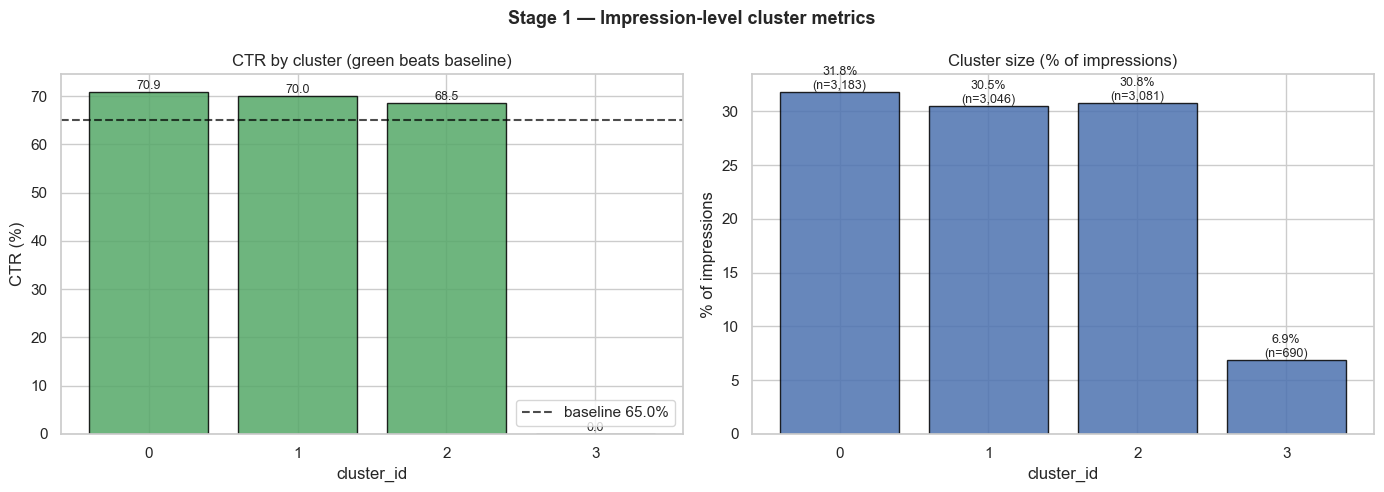

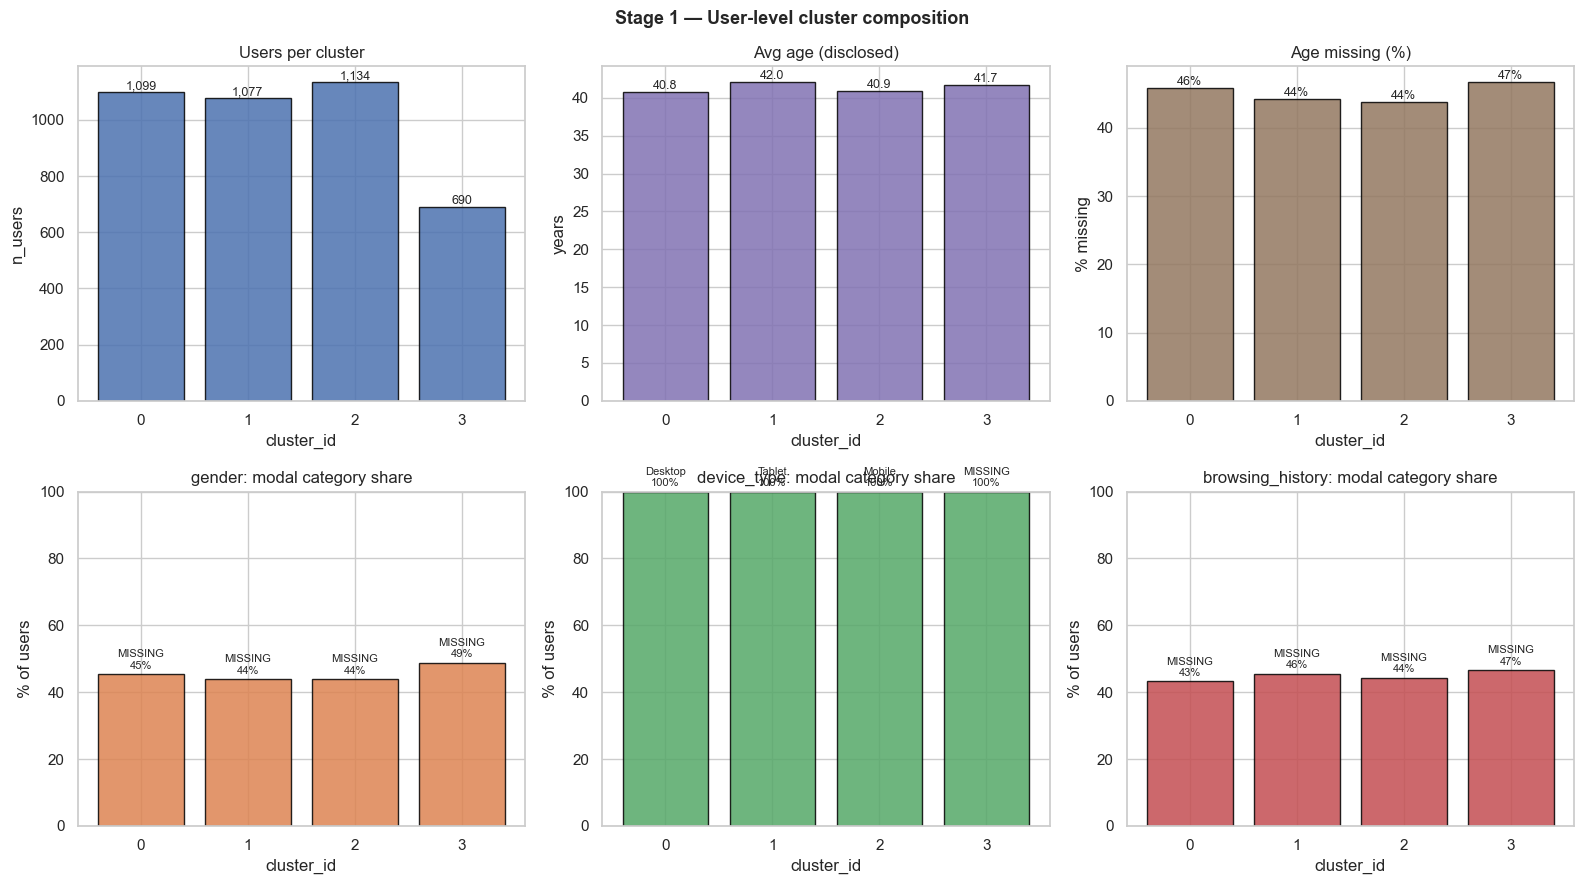

In [32]:
def plot_impression_cluster_metrics(
    metrics: pd.DataFrame,
    baseline_ctr: float = overall_ctr,
    title: str = "Stage 1 — Impression-level cluster metrics",
) -> None:
    """Bar charts of per-cluster CTR (vs baseline) and cluster size."""
    m = metrics.sort_index()
    clusters = m.index.astype(str)
    baseline_pct = baseline_ctr * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # CTR vs baseline
    ax = axes[0]
    colors = ["C2" if v >= baseline_pct else "C3" for v in m["ctr"]]
    bars = ax.bar(clusters, m["ctr"], color=colors, edgecolor="black", alpha=0.85)
    ax.axhline(baseline_pct, linestyle="--", color="black", alpha=0.7,
               label=f"baseline {baseline_pct:.1f}%")
    ax.set_title("CTR by cluster (green beats baseline)")
    ax.set_xlabel("cluster_id")
    ax.set_ylabel("CTR (%)")
    ax.legend(loc="lower right")
    for b, v in zip(bars, m["ctr"]):
        ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.1f}",
                ha="center", va="bottom", fontsize=9)

    # Cluster size
    ax = axes[1]
    bars = ax.bar(clusters, m["pct_of_impressions"], color="C0",
                  edgecolor="black", alpha=0.85)
    ax.set_title("Cluster size (% of impressions)")
    ax.set_xlabel("cluster_id")
    ax.set_ylabel("% of impressions")
    for b, v, n in zip(bars, m["pct_of_impressions"], m["n_impressions"]):
        ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.1f}%\n(n={n:,})",
                ha="center", va="bottom", fontsize=9)

    fig.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


def plot_user_cluster_metrics(
    metrics: pd.DataFrame,
    cat_cols: tuple[str, ...] = ("gender", "device_type", "browsing_history"),
    title: str = "Stage 1 — User-level cluster composition",
) -> None:
    """2x3 grid: size / avg age / age-missingness, then modal share per categorical."""
    m = metrics.sort_index()
    clusters = m.index.astype(str)

    fig, axes = plt.subplots(2, 3, figsize=(16, 9))

    def _bars(ax, values, color, fmt, ylabel, panel_title):
        bars = ax.bar(clusters, values, color=color, edgecolor="black", alpha=0.85)
        ax.set_title(panel_title)
        ax.set_xlabel("cluster_id")
        ax.set_ylabel(ylabel)
        for b, v in zip(bars, values):
            ax.text(b.get_x() + b.get_width() / 2, v, fmt(v),
                    ha="center", va="bottom", fontsize=9)
        return bars

    # Row 0 — numeric user-level descriptors
    _bars(axes[0, 0], m["n_users"], "C0", lambda v: f"{int(v):,}",
          "n_users", "Users per cluster")
    _bars(axes[0, 1], m["avg_age"], "C4", lambda v: f"{v:.1f}",
          "years", "Avg age (disclosed)")
    if "pct_age_missing" in m.columns:
        _bars(axes[0, 2], m["pct_age_missing"], "C5", lambda v: f"{v:.0f}%",
              "% missing", "Age missing (%)")
    else:
        axes[0, 2].axis("off")

    # Row 1 — modal category share per categorical, mode label printed on the bar
    for j, col in enumerate(cat_cols[:3]):
        ax = axes[1, j]
        pct = m[f"{col}_mode_pct"]
        modes = m[f"{col}_mode"]
        bars = ax.bar(clusters, pct, color=f"C{j + 1}", edgecolor="black", alpha=0.85)
        ax.set_title(f"{col}: modal category share")
        ax.set_xlabel("cluster_id")
        ax.set_ylabel("% of users")
        ax.set_ylim(0, 100)
        for b, p, label in zip(bars, pct, modes):
            ax.text(b.get_x() + b.get_width() / 2, p + 1,
                    f"{label}\n{p:.0f}%", ha="center", va="bottom", fontsize=8)

    fig.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


plot_impression_cluster_metrics(stage1_metrics)
plot_user_cluster_metrics(stage1_user_metrics)

### 5.8 Stage 1 Verdict — K-Means at K = 4
  
  **Finding.** K-Means partitions the 4,000 users into four device-defined segments: Desktop (cluster 0), Tablet (cluster 1), Mobile (cluster 2), and an
  unrecorded-device group (cluster 3). The headline business signal lives entirely in cluster 3 — 690 users (17.25%) who collectively received 690
  impressions and recorded **zero clicks (0.00% CTR)**. The remaining three clusters cluster tightly between 68.48% and 70.94% CTR — real but small
  separation (~2.5 pp), with Desktop slightly ahead.

  **Recommendation.** Withdraw the 6.90% of impression budget currently spent on the unrecorded-device segment (cluster 3) and redistribute it across
  clusters 0, 1, 2. Tilt the redistribution toward cluster 0 (Desktop) — it leads on both CTR (70.94%) and user count (1,099 users). Expected overall CTR
   uplift: **65.00% → ~69.82% (+4.82 pp absolute, +7.4% relative)**, assuming freed impressions reach users at each cluster's observed CTR.
  
  **Methodology limitation.** K-Means at K=4 mechanically partitioned the data by `device_type` — the only categorical with four nearly-equal-sized
  groups. Per-cluster `gender` and `browsing_history` distributions are essentially indistinguishable (modes are "MISSING" at 43–49% in every cluster).
  The segmentation captured the data's strongest available structure but did not surface joint demographic patterns. Stage 2 (Autoencoder + K-Means) is
  the next test of whether a learned latent representation produces richer, multi-feature segments.